In [ ]:
# import packages
from tifffile import TiffFile
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage.transform import rescale
from tqdm import tqdm  
import pandas as pd
import time
import pickle
import types
import os
import scipy
import psutil
import itertools
import re
import skimage

import seaborn as sns
import scanpy as sc

import importlib

sc.set_figure_params(dpi=80)

# %load_ext line_profiler # only needed for profiling functions

In [ ]:
def imnormalize(img, quantile_low = 0.1, quantile_high = 0.99):
    img = img - np.quantile(np.ravel(img), quantile_low)
    img = img / np.quantile(np.ravel(img), quantile_high)
    img = np.clip(img, 0, 1)
    return(img)

def im2rgb(IM, color, quantile_high = 0.99, quantile_low = 0.1):
    norm = imnormalize(IM, quantile_low = quantile_low, quantile_high = quantile_high)
    RGB = np.zeros(list(norm.shape) + [3])
    for i in range(len(color)):
        RGB[...,i] = color[i] * norm
    return(RGB)

def imblend(G, R = [], B = []):
    G = im2rgb(G, [0,1,0])
    if len(R) > 0:
        R = im2rgb(R, [1,0,0])
    else:
        R = np.zeros(R.shape)
    if len(B) > 0:
        B = im2rgb(B, [0,0,1])
    else:
        B = np.zeros(B.shape)
    IM = R + G + B
    return(IM)

def imoverlay(IM, mask, color=[1,1,1], px=0):
    from skimage.segmentation import find_boundaries
    if len(IM.shape) == 2:
        overlay_data = im2rgb(IM, [1,1,1])
    else:
        overlay_data = IM.copy()
    boundary = find_boundaries(mask, connectivity=1, mode='inner')
    boundary_mask = np.zeros(overlay_data.shape[:2])
    boundary_mask[boundary > 0] = 1
    if px > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(px,px))
        boundary_mask = cv2.dilate(boundary_mask,kernel,iterations = 1)
    for i in range(len(color)):
        overlay_data[boundary_mask > 0,i] = color[i]
    return(overlay_data)


In [ ]:
def plot_individual_category(
    adata, 
    coord_name, 
    obs_name, 
    selected_values, 
    condition_colors, 
    alpha = 1, 
    s=0.1, 
    frameon=True, 
    figsize_max = 10, 
    ax = None,
    rasterized = True, 
    background_color = 'lightgray', 
    use_outlines = True, 
    axes_color = 'white',
    scale_1 = 5,
    scale_2 = 10,
    scale_3 = 20
):
    x = adata.obsm[coord_name][:,0]
    y = adata.obsm[coord_name][:,1]
    max_x = np.max(x) - np.min(x)
    max_y = np.max(y) - np.min(y)
    if(max_x > max_y):
        figsize = [figsize_max, figsize_max*max_y/max_x]
    else:
        figsize = [figsize_max*max_x/max_y, figsize_max]
    #figsize = [figsize_max, figsize_max]
    conditions = adata.obs[obs_name]
    colors = np.array([condition_colors[x] if x != None else 'lightgray' for x in ismember(conditions, selected_values)[0]])    
    subcells = ismember(conditions, selected_values)[1]
    point_order = np.random.permutation(np.sum(subcells))
    if ax is None:
        f, ax = plt.subplots(1,1,figsize=figsize, dpi=150)
        if not frameon:
            ax.set_xticks([])
            ax.set_yticks([])
        ax.set_facecolor(axes_color)
        if(use_outlines):
            ax.scatter(x,y, facecolor='black', edgecolor='none', marker = 'o', linewidth=0, s=s*scale_3, alpha = 1, rasterized = rasterized)
            ax.scatter(x,y, facecolor='white', edgecolor='none', marker = 'o', linewidth=0, s=s*scale_2, alpha = 1, rasterized = rasterized)
        ax.scatter(x,y, facecolor=background_color, edgecolor='none', marker = 'o', linewidth=0, s=s*scale_1, alpha = 1, rasterized = rasterized)
    ax.scatter(x[subcells][point_order],y[subcells][point_order], facecolor=colors[subcells][point_order], edgecolor=None, linewidth=0, s=s*scale_1, alpha = alpha, rasterized = rasterized)
    ax.grid(False)
    return(ax)

In [ ]:
def filter_coordinates(coord, xlim, ylim):
    if isinstance(coord, pd.DataFrame):
        coord = coord.to_numpy()
    valid_points = (coord[:,0] > xlim[0]) & (coord[:,0] < xlim[1]) & (coord[:,1] > ylim[0]) & (coord[:,1] < ylim[1])
    return valid_points

def query_region(adata, coord, xlim, ylim):
    valid_points = filter_coordinates(adata.obsm[coord], xlim, ylim)
    adata_sub = adata[valid_points,:].copy()
    return(adata_sub)


In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def write_object(myObject, file):
    import dill
    with open(file, 'wb') as f:
        f.write(dill.dumps(myObject))

def read_object(file):
    import dill
    with open(file, 'rb') as f:
        myObject = dill.loads(f.read())
    return myObject

def flatten(my_list):
    return(list(itertools.chain(*my_list)))
    
def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

### Load dataset

In [ ]:
preprocessed_path = "../preprocessed/"
possible_files = os.listdir(preprocessed_path)

In [ ]:
result = []
for my_file in possible_files:
    adata_temp = sc.read_h5ad(os.path.join(preprocessed_path, my_file))
    adata_temp.X = adata_temp.layers['raw'].copy()
    sc.pp.log1p(adata_temp)
    sc.pp.scale(adata_temp)
    result.append(adata_temp)

In [ ]:
adata = sc.concat(result)

In [ ]:
obs_path = "../obs/"
possible_files = grep("csv", os.listdir(obs_path))

In [ ]:
result = []
for my_file in possible_files:
    result.append(pd.read_csv(os.path.join(obs_path, my_file), index_col = 0))

In [ ]:
result = pd.concat(result)

In [ ]:
result = result.loc[adata.obs_names.to_numpy(),:].copy()
adata.obs = result.copy()

In [ ]:
condition_map = {
    'JR-sp-15-011': 'vehicle',
    'JR-sp-15-010': 'mrtx',
    'JR-sp-40-11': 'vehicle',
    'JR-sp-40-13': 'mrtx',
    'JR-sp-40-17': 'mrtx',    
}
adata.obs['condition'] = adata.obs['slide_id'].map(condition_map)

### Representative image

In [ ]:
selected_slide = 'JR-sp-40-13'
adata_sub = adata[adata.obs['slide_id'] == selected_slide,:].copy()
bounding_box = [[5500,8500],[16700,18500]]
adata_sub = query_region(adata_sub, "X_spatial", bounding_box[0], bounding_box[1])

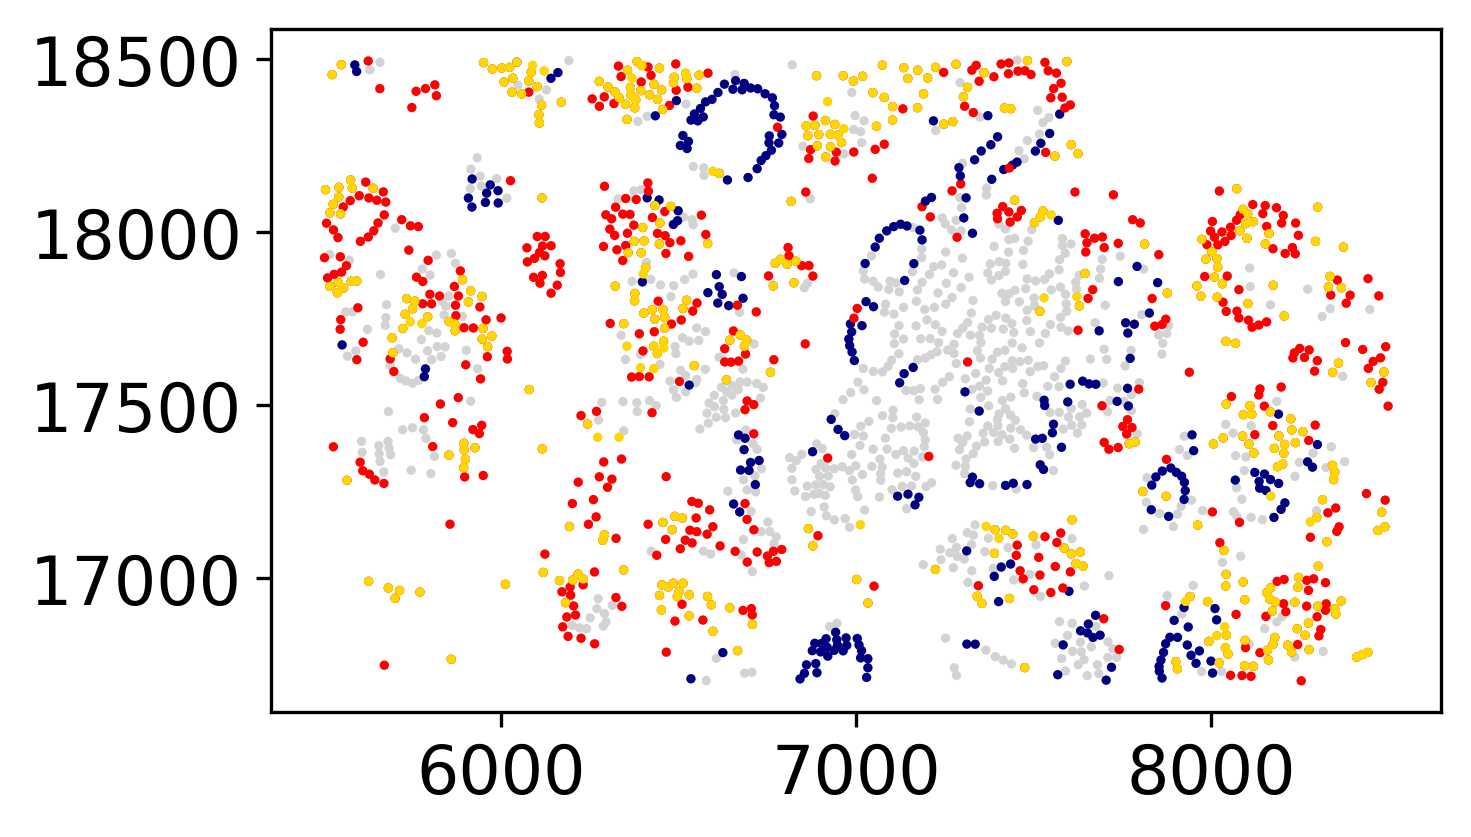

In [ ]:
ax = plot_individual_category(
    adata_sub,
    "X_spatial",
    "cell_type_0",
    ["progenitor", "gastric"],
    ["red", "navy"],
    use_outlines=False,
    figsize_max=5,
    s = 1,
)

ax = plot_individual_category(
    adata_sub,
    "X_spatial",
    "cc3_positive",
    [True],
    ["gold"],
    use_outlines=False,
    figsize_max=5,
    ax = ax,
    s = 1,
)

### Read spatialdata

In [ ]:
from spatialdata import SpatialData
import spatialdata as sd

def get_image(sdata, key, scale, channel):
    channels = np.array(sd.models.get_channel_names(sdata.images[key])).tolist()
    idx = channels.index(channel)
    return sdata.images[key][scale].image[idx].values

def get_image_slice(sdata, key, scale, channel, row_slice, col_slice):
    channels = np.array(sd.models.get_channel_names(sdata.images[key])).tolist()
    idx = channels.index(channel)
    return sdata.images[key][scale].image[idx][row_slice, col_slice].compute().values


/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
sdata = sd.read_zarr(os.path.join("../sdata", selected_slide))

version mismatch: detected: RasterFormatV02, requested: FormatV04
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-

In [ ]:
row_slice = slice(bounding_box[0][0], bounding_box[0][1])
col_slice = slice(bounding_box[1][0], bounding_box[1][1])


In [ ]:
output_dir = "../images"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
selected_markers = ["MSN", "HMGA2", "p19", "LGALS4", "ANXA10", "CPA1", "GFP", "CC3", "DAPI"]
for my_marker in selected_markers:
    IM = get_image_slice(sdata, "COMET", "scale1", my_marker, row_slice, col_slice)
    skimage.io.imsave(os.path.join(output_dir, selected_slide + "_" + my_marker + ".tif"), IM)

/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_MSN.tif is a low contrast image
  return func(*args, **kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_HMGA2.tif is a low contrast image
  return func(*args, **kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_p19.tif is a low contrast image
  return func(*args, **kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_LGALS4.tif is a low contrast image
  return func(*args, **kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_ANXA10.tif is a low contrast image
  return func(*args, **kwargs)
/data1/lowes

In [ ]:
manual_mask_image = skimage.io.imread("../manual_masks/20251126_131206_1_R0D41L_JR_NP_Revision_C_JR-sp-40-13_backgroundSub.ome-labels.ome.tif")
mask_slice = manual_mask_image[row_slice, col_slice]

In [ ]:
skimage.io.imsave(os.path.join(output_dir, selected_slide + "_" + "mask" + ".tif"), mask_slice)

/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/skimage/_shared/utils.py:328: UserWarning: images/JR-sp-40-13_mask.tif is a low contrast image
  return func(*args, **kwargs)


In [ ]:
MSN = get_image_slice(sdata, "COMET", "scale1", "MSN", row_slice, col_slice)
HMGA2 = get_image_slice(sdata, "COMET", "scale1", "HMGA2", row_slice, col_slice)
p19 = get_image_slice(sdata, "COMET", "scale1", "p19", row_slice, col_slice)
LGALS4 = get_image_slice(sdata, "COMET", "scale1", "LGALS4", row_slice, col_slice)
ANXA10 = get_image_slice(sdata, "COMET", "scale1", "ANXA10", row_slice, col_slice)
CPA1 = get_image_slice(sdata, "COMET", "scale1", "CPA1", row_slice, col_slice)
DAPI = get_image_slice(sdata, "COMET", "scale1", "DAPI", row_slice, col_slice)
GFP = get_image_slice(sdata, "COMET", "scale1", "GFP", row_slice, col_slice)
CC3 = get_image_slice(sdata, "COMET", "scale1", "CC3", row_slice, col_slice)


In [ ]:
cpa1 = im2rgb(CPA1, [0,1,1])
lgals4 = im2rgb(CPA1, [1,0,1])
anxa10 = im2rgb(ANXA10, [1,1,0])
dapi = im2rgb(DAPI, [0,0,1])
gfp = im2rgb(GFP, [1,0,0])

composite = cpa1 + lgals4 + anxa10 + dapi + gfp

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..2.9871441689623506].


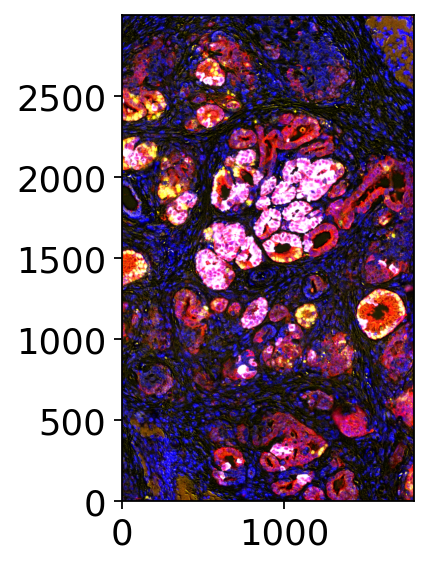

In [ ]:
plt.imshow(composite)
plt.gca().invert_yaxis()